In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math
from PIL import Image
from numba import njit, prange


In [2]:
Tp = 5e-3
ir_thresh = 0.20
min_ir_sep_s = 0.025

delta_x = 0.011
h_radar_ft = 6
h_radar_m = h_radar_ft * 0.3048

c = 3e8
fstart = 2280e6
fstop = 2580e6
B = fstop - fstart
fc = (fstart + fstop) / 2

range_gate_ft = 8.0
range_gate_fade_ft = 1.0

debug_zpad = 8192
debug_max_bin = 700
debug_dynamic_range = 20


def get_range_profiles(filename):
    FS, Y = wavfile.read(filename)
    Y = Y.astype(np.float32)

    if Y.ndim == 1:
        raise ValueError("WAV is mono. Expected multichannel WAV.")

    if np.max(np.abs(Y)) > 1:
        Y = Y / np.max(np.abs(Y))

    radar_raw = Y[:, 1]
    sync_raw = Y[:, 2]
    ir_raw = Y[:, 3]

    N = int(round(Tp * FS))

    sync_bool = (sync_raw > 0).astype(np.int8)
    ir_bool = (np.abs(ir_raw) > ir_thresh).astype(np.int8)

    sync_starts = np.where(np.diff(sync_bool) == 1)[0] + 1
    ir_edges = np.where(np.diff(ir_bool) == 1)[0] + 1

    min_dist = int(FS * min_ir_sep_s)
    valid_ir = []
    last_c = -min_dist

    for edge in ir_edges:
        if edge > last_c + min_dist:
            valid_ir.append(edge)
            last_c = edge

    valid_ir = np.array(valid_ir)

    sif_time = []
    used_ir = []
    used_sync = []

    for edge in valid_ir:
        idx_s = np.argmin(np.abs(sync_starts - edge))
        bst = int(sync_starts[idx_s])

        if bst + N <= len(radar_raw):
            sif_time.append(radar_raw[bst:bst + N])
            used_ir.append(edge)
            used_sync.append(bst)

    sif_time = np.array(sif_time)
    used_ir = np.array(used_ir)
    used_sync = np.array(used_sync)

    if len(sif_time) == 0:
        raise ValueError("No valid pulses found.")

    sif_time = sif_time - np.mean(sif_time, axis=1, keepdims=True)

    win = np.hanning(N)
    range_profiles_complex = np.fft.fft(sif_time * win[None, :], axis=1)
    # range_profiles_complex = np.fft.ifft(sif_time, axis=1)

    range_res_m = c / (2 * B)
    gate_m = range_gate_ft * 0.3048
    fade_m = range_gate_fade_ft * 0.3048

    stop_bins = int(round(gate_m / range_res_m))
    fade_bins = int(round(fade_m / range_res_m))

    mask = np.ones(range_profiles_complex.shape[1], dtype=np.float32)

    if stop_bins < len(mask) // 2:
        mask[:stop_bins] = 0
        mask[-stop_bins:] = 0

        if fade_bins > 0:
            ramp_up = np.linspace(0, 1, fade_bins)
            ramp_down = np.linspace(1, 0, fade_bins)

            a0 = stop_bins
            a1 = min(stop_bins + fade_bins, len(mask))
            mask[a0:a1] = ramp_up[:a1 - a0]

            b1 = len(mask) - stop_bins
            b0 = max(0, b1 - fade_bins)
            mask[b0:b1] = ramp_down[-(b1 - b0):]

    range_profiles_complex = range_profiles_complex * mask[None, :]

    q_debug = np.fft.ifft(sif_time, n=debug_zpad, axis=1)

    debug_mask = np.ones(debug_zpad, dtype=np.float32)
    scale = debug_zpad / range_profiles_complex.shape[1]
    stop_debug = int(round(stop_bins * scale))
    fade_debug = int(round(fade_bins * scale))

    if stop_debug < debug_zpad // 2:
        debug_mask[:stop_debug] = 0
        debug_mask[-stop_debug:] = 0

        if fade_debug > 0:
            ramp_up = np.linspace(0, 1, fade_debug)
            ramp_down = np.linspace(1, 0, fade_debug)

            a0 = stop_debug
            a1 = min(stop_debug + fade_debug, debug_zpad)
            debug_mask[a0:a1] = ramp_up[:a1 - a0]

            b1 = debug_zpad - stop_debug
            b0 = max(0, b1 - fade_debug)
            debug_mask[b0:b1] = ramp_down[-(b1 - b0):]

    q_debug = q_debug * debug_mask[None, :]

    range_profiles_mag = np.abs(q_debug)
    range_profiles_db = 20 * np.log10(range_profiles_mag + 1e-12)

    vmax = np.max(range_profiles_db)
    vmin = vmax - debug_dynamic_range

    num_profiles = sif_time.shape[0]

    x = np.arange(num_profiles) * delta_x
    x = x - np.mean(x)
    y = np.zeros(num_profiles)
    z = np.full(num_profiles, h_radar_m)

    radar_positions = np.column_stack([x, y, z])

    print("Pulses:", len(ir_edges))
    print("FS:", FS)
    print("N:", N)
    print("num profiles:", num_profiles)
    print("profile length:", q_debug.shape[1])
    print("range resolution m:", range_res_m)
    print("range gate bins:", stop_bins)
    print("fade bins:", fade_bins)
    print("radar_positions shape:", radar_positions.shape)
    print("first position:", radar_positions[0])
    print("last position:", radar_positions[-1])
    print("aperture width m:", np.ptp(radar_positions[:, 0]))
    peak_bins = np.argmax(range_profiles_mag, axis=1)

    # fig, ax = plt.subplots(figsize=(8, 5))

    # im = ax.imshow(
    #     range_profiles_db.T,
    #     cmap="jet",
    #     aspect="auto",
    #     origin="lower",
    #     vmin=vmin,
    #     vmax=vmax
    # )


    # ax.scatter(
    #     np.arange(len(peak_bins)),
    #     peak_bins,
    #     s=8,
    #     c="purple",
    #     marker="."
    # )

    # ax.set_ylim(0, debug_max_bin)
    # ax.set_ylabel("Bin")
    # ax.set_xlabel("Pulse")
    # ax.set_title("Range Compressed History with Peak Bins")

    # ax2 = ax.twiny()
    # ax2.set_xlim(ax.get_xlim())

    # ticks = np.linspace(0, len(radar_positions) - 1, 6)
    # ax2.set_xticks(ticks)
    # ax2.set_xticklabels([f"{radar_positions[int(t), 0]:.2f}" for t in ticks])
    # ax2.set_xlabel("Radar x-position (m)")

    # plt.colorbar(im, ax=ax, label="dB")
    # plt.show()

    range_profiles = range_profiles_complex
    return range_profiles, radar_positions

# Static

In [15]:
from Imaging import *

range_profiles, radar_positions = get_range_profiles("/Users/levifarinas/SAR Backprojection/SAR Data/UXOClass_020226_Groupmilan_experiment1.wav")
img, cr, dr = bp(
    radar_positions,
    range_profiles,
    resolution=(100, 100)
)

# plt.figure(figsize=(10, 10))
# plt.imshow(img, cmap="jet", origin="lower", extent=(0, 5*3.3, 0, 9*3.3), vmin=-40, vmax=0)
# plt.colorbar()
# plt.show()

Pulses: 341
FS: 44100
N: 220
num profiles: 340
profile length: 8192
range resolution m: 0.49965409666666666
range gate bins: 5
fade bins: 1
radar_positions shape: (340, 3)
first position: [-1.8645  0.      1.8288]
last position: [1.8645 0.     1.8288]
aperture width m: 3.7289999999999996


# Minimum Entropy Autofocus

In [9]:
import Autofocus as af

# gradient = af.find_gradient(range_profiles, radar_positions)
focused, diffs, entropy, params = af.minimum_entropy_autofocus(range_profiles, radar_positions, num_iterations=5)

In [10]:
params

{'x_offset': np.float64(3.76009301372271e-05),
 'y_offset': np.float64(1.1583271435000598e-06),
 'z_offset': np.float64(2.303527374181158e-07),
 'cable_off_ft': np.float64(0.00032792127846672516)}

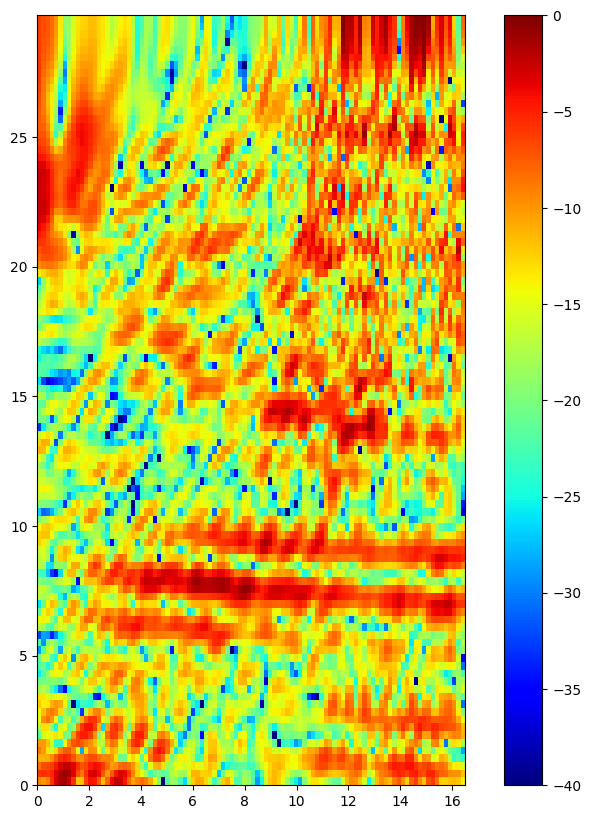

In [16]:
plt.figure(figsize=(10, 10))
# img, cr, dr = bp(
#     radar_positions,
#     range_profiles,
#     resolution=(100, 100)
# )
plt.imshow(np.flipud(img.T), cmap="jet", origin="lower", extent=(0, 5*3.3, 0, 9*3.3), vmin=-40, vmax=0)
plt.colorbar()
plt.show()

# Animation

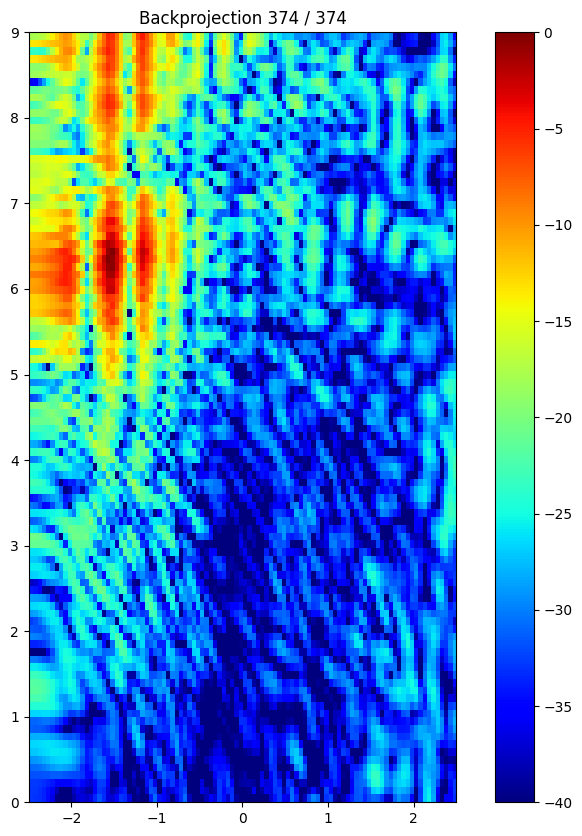

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots(figsize=(10, 10))
empty = np.full((300, 300), -40.0)

im = ax.imshow(
    empty,
    cmap="jet",
    origin="lower",
    extent=(-2.5, 2.5, 0, 9),
    vmin=-40,
    vmax=0,
    animated=True
)

cb = plt.colorbar(im, ax=ax)
title = ax.set_title("Backprojection 0 / 0")
num_frames = len(radar_positions)
def update(frame):
    k = frame + 1
    img = bp(
        radar_positions[:k],
        range_profiles[:k],
        resolution=(100,100)
    )
    img = np.asarray(img)
    if np.iscomplexobj(img):
        img = np.abs(img)
    img = bp(radar_positions[:k], range_profiles[:k])
    im.set_data(img)
    title.set_text(f"Backprojection {k} / {num_frames}")
    return im, title

ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    interval=50,
    blit=False,
    repeat=True
)
ani.save("backprojection.mp4", fps=30, dpi=150)
plt.show()